26/03/2026 Thursday H5

n_gram_sequence : How many words we are considering 

grams ; for every combination,for every word in vocab we are creating a unique id, when we create embedding we conver them to vectors

 append : appended to the previous sequences

 Padding : n gram are of different length , prepad them.

  max_length = sentence with max no of words , last column as y_label

**Notes**
For every sentence in corpus we are creating the dataset

Here only preprocessing matters

one hot encoding,categorical_crossentropy else sparsecategorical_crossentropy


In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf 
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM , Dense, Dropout,Embedding
from tensorflow.keras.utils import to_categorical

In [3]:
corpus = [
    "I love machine learning",
    "LSTM networks are great for sequence prediction",
    "I enjoy building models with keras",
    "Deep learning is fascinating",
    "Natural language processing is a part of AI"
]

tokenizer = Tokenizer()
tokenizer.fit_on_texts(corpus)
total_words = len(tokenizer.word_index) + 1 #to accommodate padding
#Create input sequences and labels
input_sequences = []
for line in corpus:
    token_list = tokenizer.texts_to_sequences([line])[0] #Converts the input text (a single line ) into a sequence of 
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        print(n_gram_sequence)
        input_sequences.append(n_gram_sequence)

max_len = max([len(x) for x in input_sequences])
input_sequences = pad_sequences(input_sequences,maxlen=max_len, padding='pre')
print(input_sequences)

#create features and labels
x,y = input_sequences[:,:-1],input_sequences[:,-1]
y = tf.keras.utils.to_categorical(y,num_classes=total_words)

[1, 4]
[1, 4, 5]
[1, 4, 5, 2]
[6, 7]
[6, 7, 8]
[6, 7, 8, 9]
[6, 7, 8, 9, 10]
[6, 7, 8, 9, 10, 11]
[6, 7, 8, 9, 10, 11, 12]
[1, 13]
[1, 13, 14]
[1, 13, 14, 15]
[1, 13, 14, 15, 16]
[1, 13, 14, 15, 16, 17]
[18, 2]
[18, 2, 3]
[18, 2, 3, 19]
[20, 21]
[20, 21, 22]
[20, 21, 22, 3]
[20, 21, 22, 3, 23]
[20, 21, 22, 3, 23, 24]
[20, 21, 22, 3, 23, 24, 25]
[20, 21, 22, 3, 23, 24, 25, 26]
[[ 0  0  0  0  0  0  1  4]
 [ 0  0  0  0  0  1  4  5]
 [ 0  0  0  0  1  4  5  2]
 [ 0  0  0  0  0  0  6  7]
 [ 0  0  0  0  0  6  7  8]
 [ 0  0  0  0  6  7  8  9]
 [ 0  0  0  6  7  8  9 10]
 [ 0  0  6  7  8  9 10 11]
 [ 0  6  7  8  9 10 11 12]
 [ 0  0  0  0  0  0  1 13]
 [ 0  0  0  0  0  1 13 14]
 [ 0  0  0  0  1 13 14 15]
 [ 0  0  0  1 13 14 15 16]
 [ 0  0  1 13 14 15 16 17]
 [ 0  0  0  0  0  0 18  2]
 [ 0  0  0  0  0 18  2  3]
 [ 0  0  0  0 18  2  3 19]
 [ 0  0  0  0  0  0 20 21]
 [ 0  0  0  0  0 20 21 22]
 [ 0  0  0  0 20 21 22  3]
 [ 0  0  0 20 21 22  3 23]
 [ 0  0 20 21 22  3 23 24]
 [ 0 20 21 22  3 23 24 25]


In [5]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [6]:
model = Sequential()
model.add(Embedding(total_words,100,input_length=max_len-1))
model.add(LSTM(150))
model.add(Dropout(0.2))
model.add(Dense(total_words,activation='softmax'))

model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

c:\Users\user\Desktop\MCA AI DS 2027\S2\Deep Learning\Lab\tfenv\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [7]:
history = model.fit(x_train, y_train, epochs=100, batch_size=64, validation_data=(x_test, y_test))

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.0000e+00 - loss: 3.2955 - val_accuracy: 0.0000e+00 - val_loss: 3.3007
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.1053 - loss: 3.2851 - val_accuracy: 0.0000e+00 - val_loss: 3.3071
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.2105 - loss: 3.2735 - val_accuracy: 0.0000e+00 - val_loss: 3.3140
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.3158 - loss: 3.2648 - val_accuracy: 0.0000e+00 - val_loss: 3.3223
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.3684 - loss: 3.2475 - val_accuracy: 0.0000e+00 - val_loss: 3.3317
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.2105 - loss: 3.2400 - val_accuracy: 0.0000e+00 - val_loss: 3.3426
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.3158 - loss: 3.2185 - val_accuracy: 0.0000e+00 - val_loss: 3.3562
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.2105 - loss: 3.20

In [8]:
def predict_next_word(text):
    token_list = tokenizer.texts_to_sequences([text])[0]
    token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
    predicted = model.predict(token_list, verbose=0)
    return tokenizer.index_word[np.argmax(predicted)]

#Example usage
input_text = "I Love"
predicted_word = predict_next_word(input_text)
print(f"Predicted next word: {predicted_word}")

Predicted next word: machine


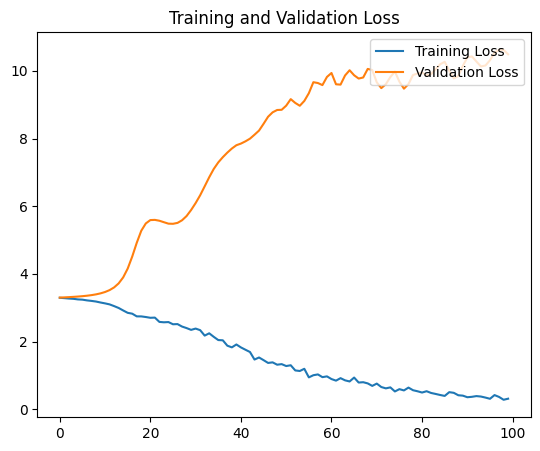

In [10]:
#plot Training and validation accuracy and loss
import matplotlib.pyplot as plt
plt.figure(figsize=(14,5))

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

#plt.savefig('./NEXT_WORD_PREDICTION_LSTM.png')
plt.show()
